# EDA for Telco Customer Churn dataset

[dataset link](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

[dataset description](https://community.ibm.com/community/user/blogs/steven-macko/2019/07/11/telco-customer-churn-1113)

In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 

pd.set_option('display.max_columns', 200)
np.random.seed(42)

## Download dataset

In [2]:
%pip install -q kagglehub

In [3]:
# download dataset from kaggle
import kagglehub # pyright: ignore[reportMissingImports]
from pathlib import Path

# Download latest version
path = Path(kagglehub.dataset_download("blastchar/telco-customer-churn"))
path = path / r"WA_Fn-UseC_-Telco-Customer-Churn.csv"

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
df = pd.read_csv(path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Preliminary analysis

In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
is_na_default = df.isna().sum()
is_na_default.name = "is_na_default"

is_na_space = df.astype(str).map(lambda x: x == "" or x == " ").sum()
is_na_space.name = "is_empty_space"

pd.concat([is_na_default, is_na_space], axis = 1)

,is_na_default,is_empty_space
customerID,0,0
gender,0,0
SeniorCitizen,0,0
Partner,0,0
Dependents,0,0
tenure,0,0
PhoneService,0,0
MultipleLines,0,0
InternetService,0,0
OnlineSecurity,0,0


In [9]:
df.duplicated().sum()

np.int64(0)

## Data preparation (basic)

In [10]:
to_category_columns = (
    [
        "gender",
        "Partner",
        "Dependents",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup", 
        "DeviceProtection",
        "TechSupport",
        "StreamingTV", 
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "Churn"
        ])
    
for column in to_category_columns:
    df[column] = df[column].astype("category")
    
df["SeniorCitizen"] = df["SeniorCitizen"] == 1
    

In [11]:
df.dtypes

,0
customerID,object
gender,category
SeniorCitizen,bool
Partner,category
Dependents,category
tenure,int64
PhoneService,category
MultipleLines,category
InternetService,category
OnlineSecurity,category


In [12]:
df["TotalCharges"]  = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


### Data NA handling

In [13]:
df["TotalCharges"].isna().sum()

np.int64(11)

As we see only 11 rows with NA values we can drop them without losing significant insights

In [14]:
print(df.shape)

df = df.dropna()
df["TotalCharges"].isna().sum()
print(df.shape)

(7043, 21)
(7032, 21)


## Data Observation

Check data distribution

In [15]:
from dataclasses import dataclass
import math

# Utilities for plot generation

@dataclass
class DiscretePlot():
    data: pd.Series
    title: str
    x_title:str | None = None
    y_title: str| None = None
    
def count_plot_sizes(len_plot_map: int) -> tuple[int, int]:
    columns = 2 if len_plot_map == 2 else 3
    if len_plot_map < columns:
        columns = len_plot_map
    
    rows = math.ceil(len_plot_map / columns)
    return rows, columns
    
def plot_discrete_vars(plot_map: list[DiscretePlot]):
    nrows, ncolumns = count_plot_sizes(len(plot_map))
    fig, axs = plt.subplots(nrows, ncolumns, figsize=(5 * ncolumns, 4 * nrows))
    
    for i, plot in enumerate(plot_map):
        ax = axs.flat[i] # type: ignore
        
        counts = plot.data.value_counts()
        sns.barplot(x=counts.index, y=counts.values, ax=ax)
        
        ax.set_title(plot.title)
        ax.set_xlabel(plot.x_title if plot.x_title else "")
        ax.set_ylabel(plot.y_title if plot.y_title else "Count")
        ax.tick_params(axis='x', labelrotation=45)
    
    total_cells = nrows * ncolumns
    if total_cells > len(plot_map):
        for j in range(len(plot_map), total_cells):
            axs.flat[j].set_visible(False) # type: ignore
    
    print("Processed", len(plot_map)," maps")
    plt.tight_layout()
    plt.show()

Processed 17  maps


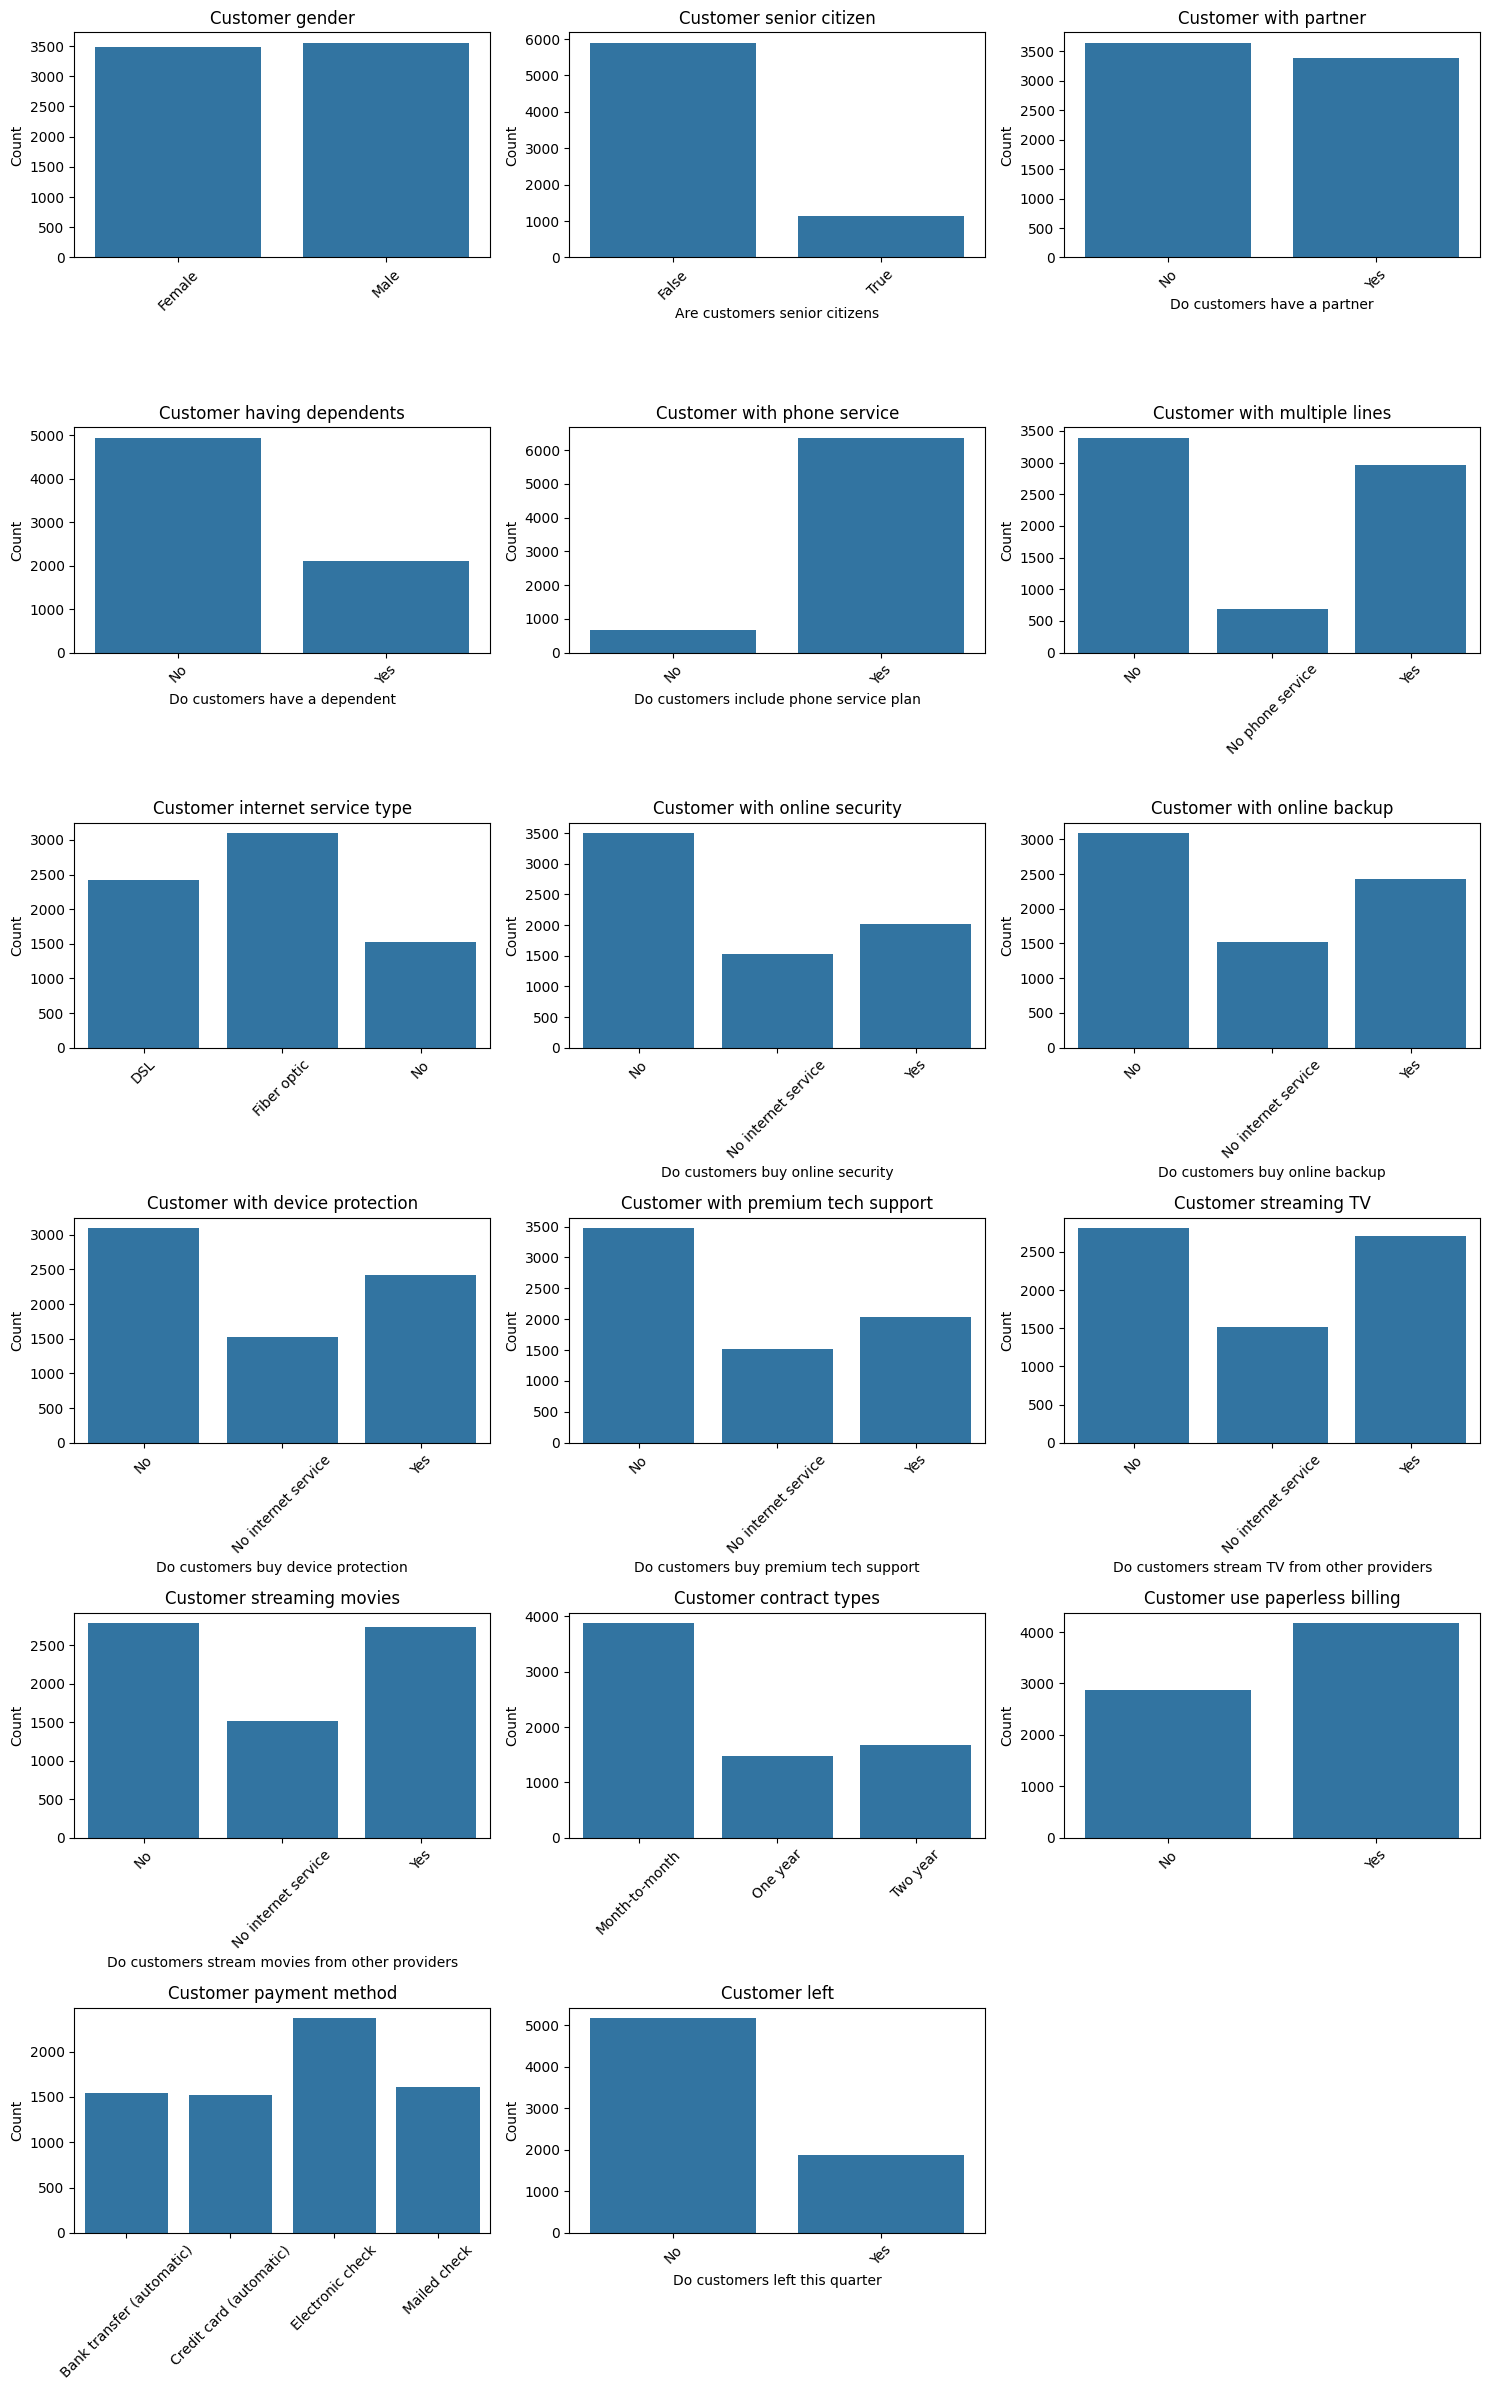

In [16]:
discrete_plot_map = [
    DiscretePlot(df["gender"], title="Customer gender"),
    DiscretePlot(df["SeniorCitizen"], title="Customer senior citizen", x_title="Are customers senior citizens"),
    DiscretePlot(df["Partner"], title="Customer with partner", x_title="Do customers have a partner"),
    DiscretePlot(df["Dependents"], title="Customer having dependents", x_title="Do customers have a dependent"),
    DiscretePlot(df["PhoneService"], title="Customer with phone service", x_title="Do customers include phone service plan"),
    DiscretePlot(df["MultipleLines"], title="Customer with multiple lines"),
    DiscretePlot(df["InternetService"], title="Customer internet service type"),
    DiscretePlot(df["OnlineSecurity"], title="Customer with online security", x_title="Do customers buy online security"),
    DiscretePlot(df["OnlineBackup"], title="Customer with online backup", x_title="Do customers buy online backup"),
    DiscretePlot(df["DeviceProtection"], title="Customer with device protection", x_title="Do customers buy device protection"),
    DiscretePlot(df["TechSupport"], title="Customer with premium tech support", x_title="Do customers buy premium tech support"),
    DiscretePlot(df["StreamingTV"], title="Customer streaming TV", x_title="Do customers stream TV from other providers"),
    DiscretePlot(df["StreamingMovies"], title="Customer streaming movies", x_title="Do customers stream movies from other providers"),
    DiscretePlot(df["Contract"], title="Customer contract types"),
    DiscretePlot(df["PaperlessBilling"], title="Customer use paperless billing"),
    DiscretePlot(df["PaymentMethod"], title="Customer payment method"),
    DiscretePlot(df["Churn"], title="Customer left", x_title="Do customers left this quarter"),
]

plot_discrete_vars(discrete_plot_map)

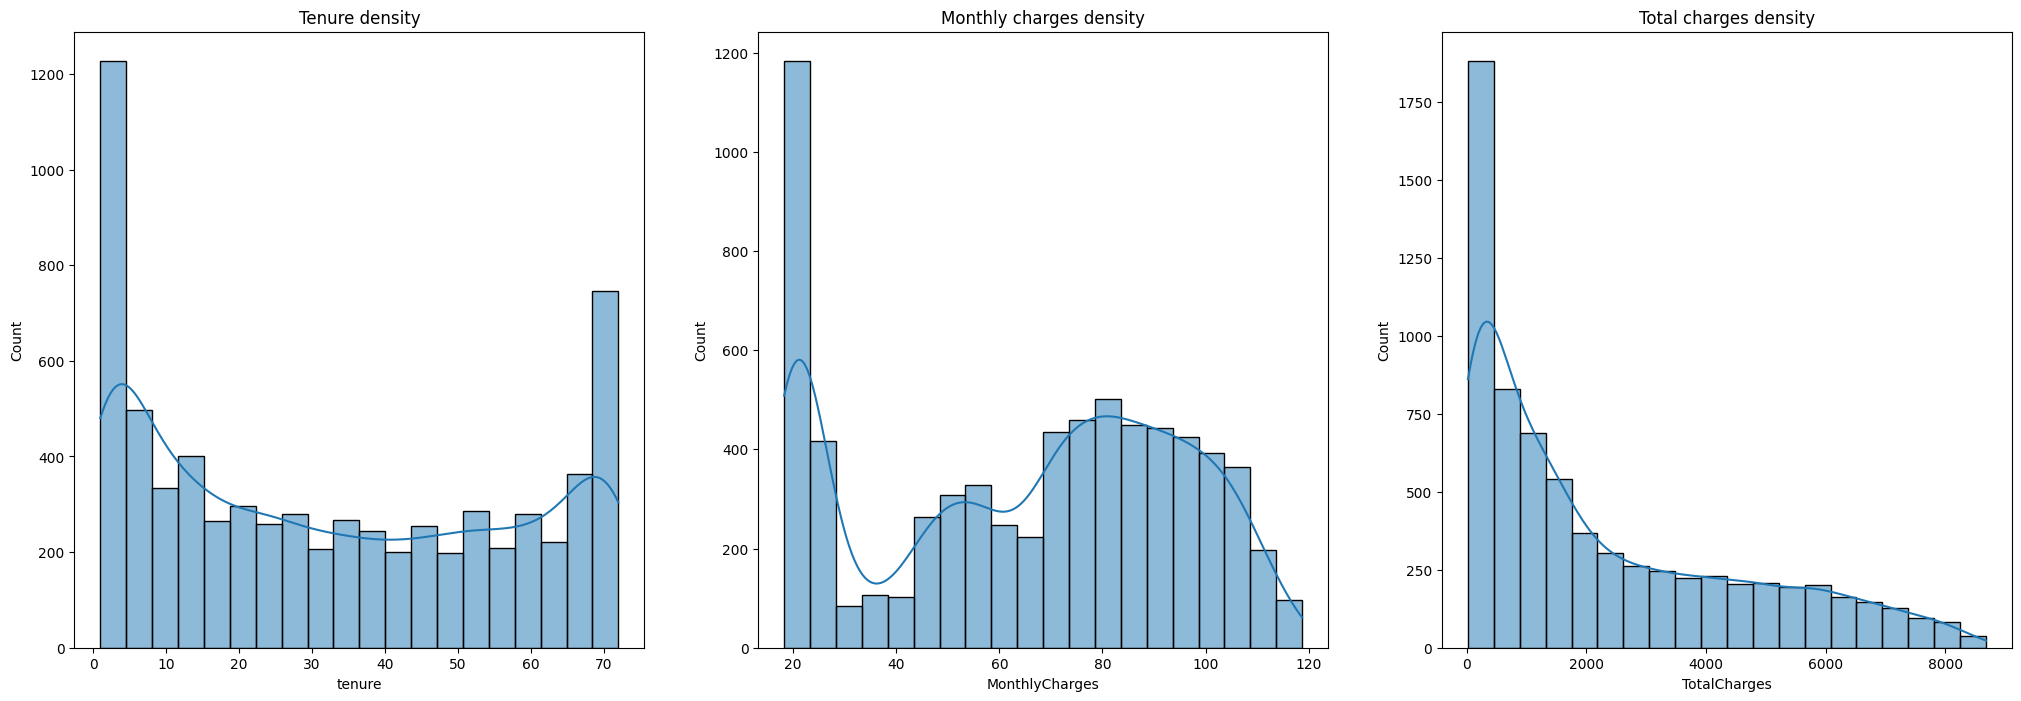

In [17]:
fig, axs = plt.subplots(1,3, figsize=(25,8))
sns.histplot(df.tenure, bins=20, kde=True, ax=axs[0])
axs[0].set_title("Tenure density")


sns.histplot(df["MonthlyCharges"], bins=20, kde=True, ax=axs[1])
axs[1].set_title("Monthly charges density")


sns.histplot(df["TotalCharges"], bins=20, kde=True)
axs[2].set_title("Total charges density")


plt.show()


## Data correlation analysis

In [18]:
from sklearn.preprocessing import LabelEncoder # type: ignore

def encode_columns(data, columns_list):
    for column in columns_list:
        data[column] = LabelEncoder().fit_transform(data[column])
    return data

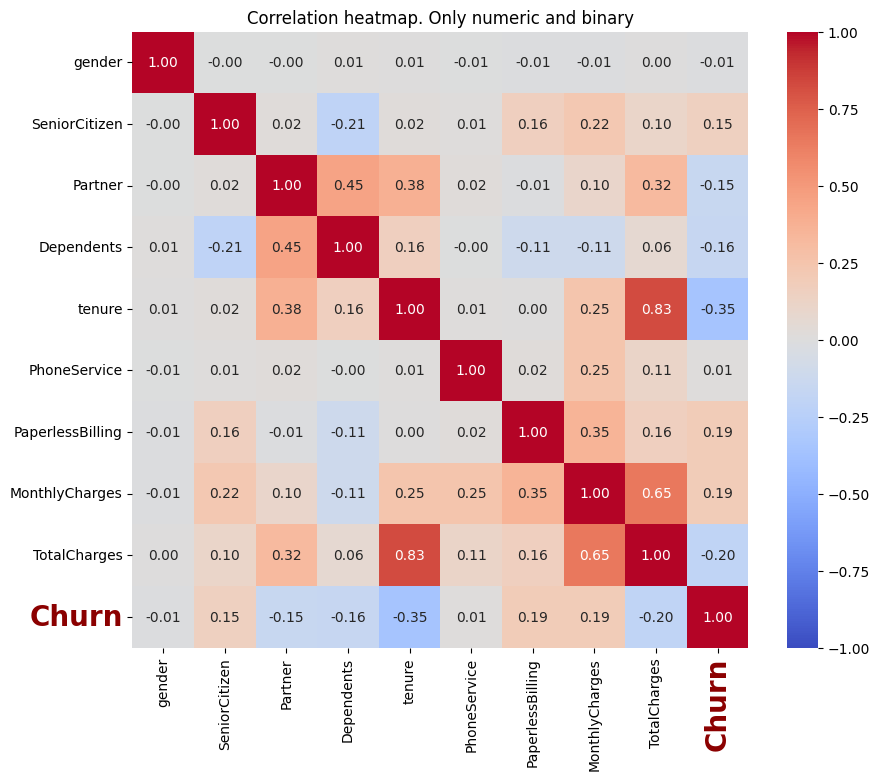

In [19]:
# Encode binary columns with LabelEncoder
binary_columns =(
        [
                "gender", 
                "SeniorCitizen", 
                "Partner", 
                "Dependents", 
                "PhoneService", 
                "PaperlessBilling", 
                "Churn"
        ])

numeric_columns = (
        [
                "tenure",
                "MonthlyCharges",
                "TotalCharges",
        ]
)

df_enc = df.copy()
df_enc = encode_columns(df_enc, binary_columns)


cols = list(df_enc.select_dtypes('number').columns)
corr = df_enc[cols].corr()

plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                 center=0, vmin=-1, vmax=1, square=True)

target = 'Churn'
for i, column in enumerate(ax.get_xticklabels()):
    if column.get_text() == target:
        column.set_color('darkred')
        column.set_fontweight('bold')
        column.set_fontsize(20)
for i, column in enumerate(ax.get_yticklabels()):
    if column.get_text() == target:
        column.set_color('darkred')
        column.set_fontweight('bold')
        column.set_fontsize(20)

plt.title("Correlation heatmap. Only numeric and binary")
plt.show()

See many small correlations with the target. And many multicollinearities (do not cover all category labels yet btw). Seems to better to use stable on multicollinearity models

### Nominal feature importance

In [20]:
from scipy.stats import chi2_contingency # pyright: ignore[reportMissingImports]

# Cramers test
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    return np.sqrt(phi2 / min(k-1, r-1))

# Define nominative features for analysis
columns_to_exclude = list(df.select_dtypes('number').columns) + ["customerID", "Churn"]
columns_to_plot = set(df.columns) - set(columns_to_exclude)

def calculate_cramers_on_data(data_frame: pd.DataFrame, columns: set[str]) -> tuple[str, np.float64]:
    """Do a cramer's V test on feature and Churn"""
    cramer_feat_relations = {}
    for col in columns:
        cramer_feat_relations[col] = cramers_v(data_frame[col], data_frame["Churn"])
    return sorted(cramer_feat_relations.items(), key= lambda item: item[1], reverse=True)


Interpretation: 0.00-0.10 negligible, 0.10-0.30 small, 0.30-0.50 medium, 0.50+ large
Processed 16  plots


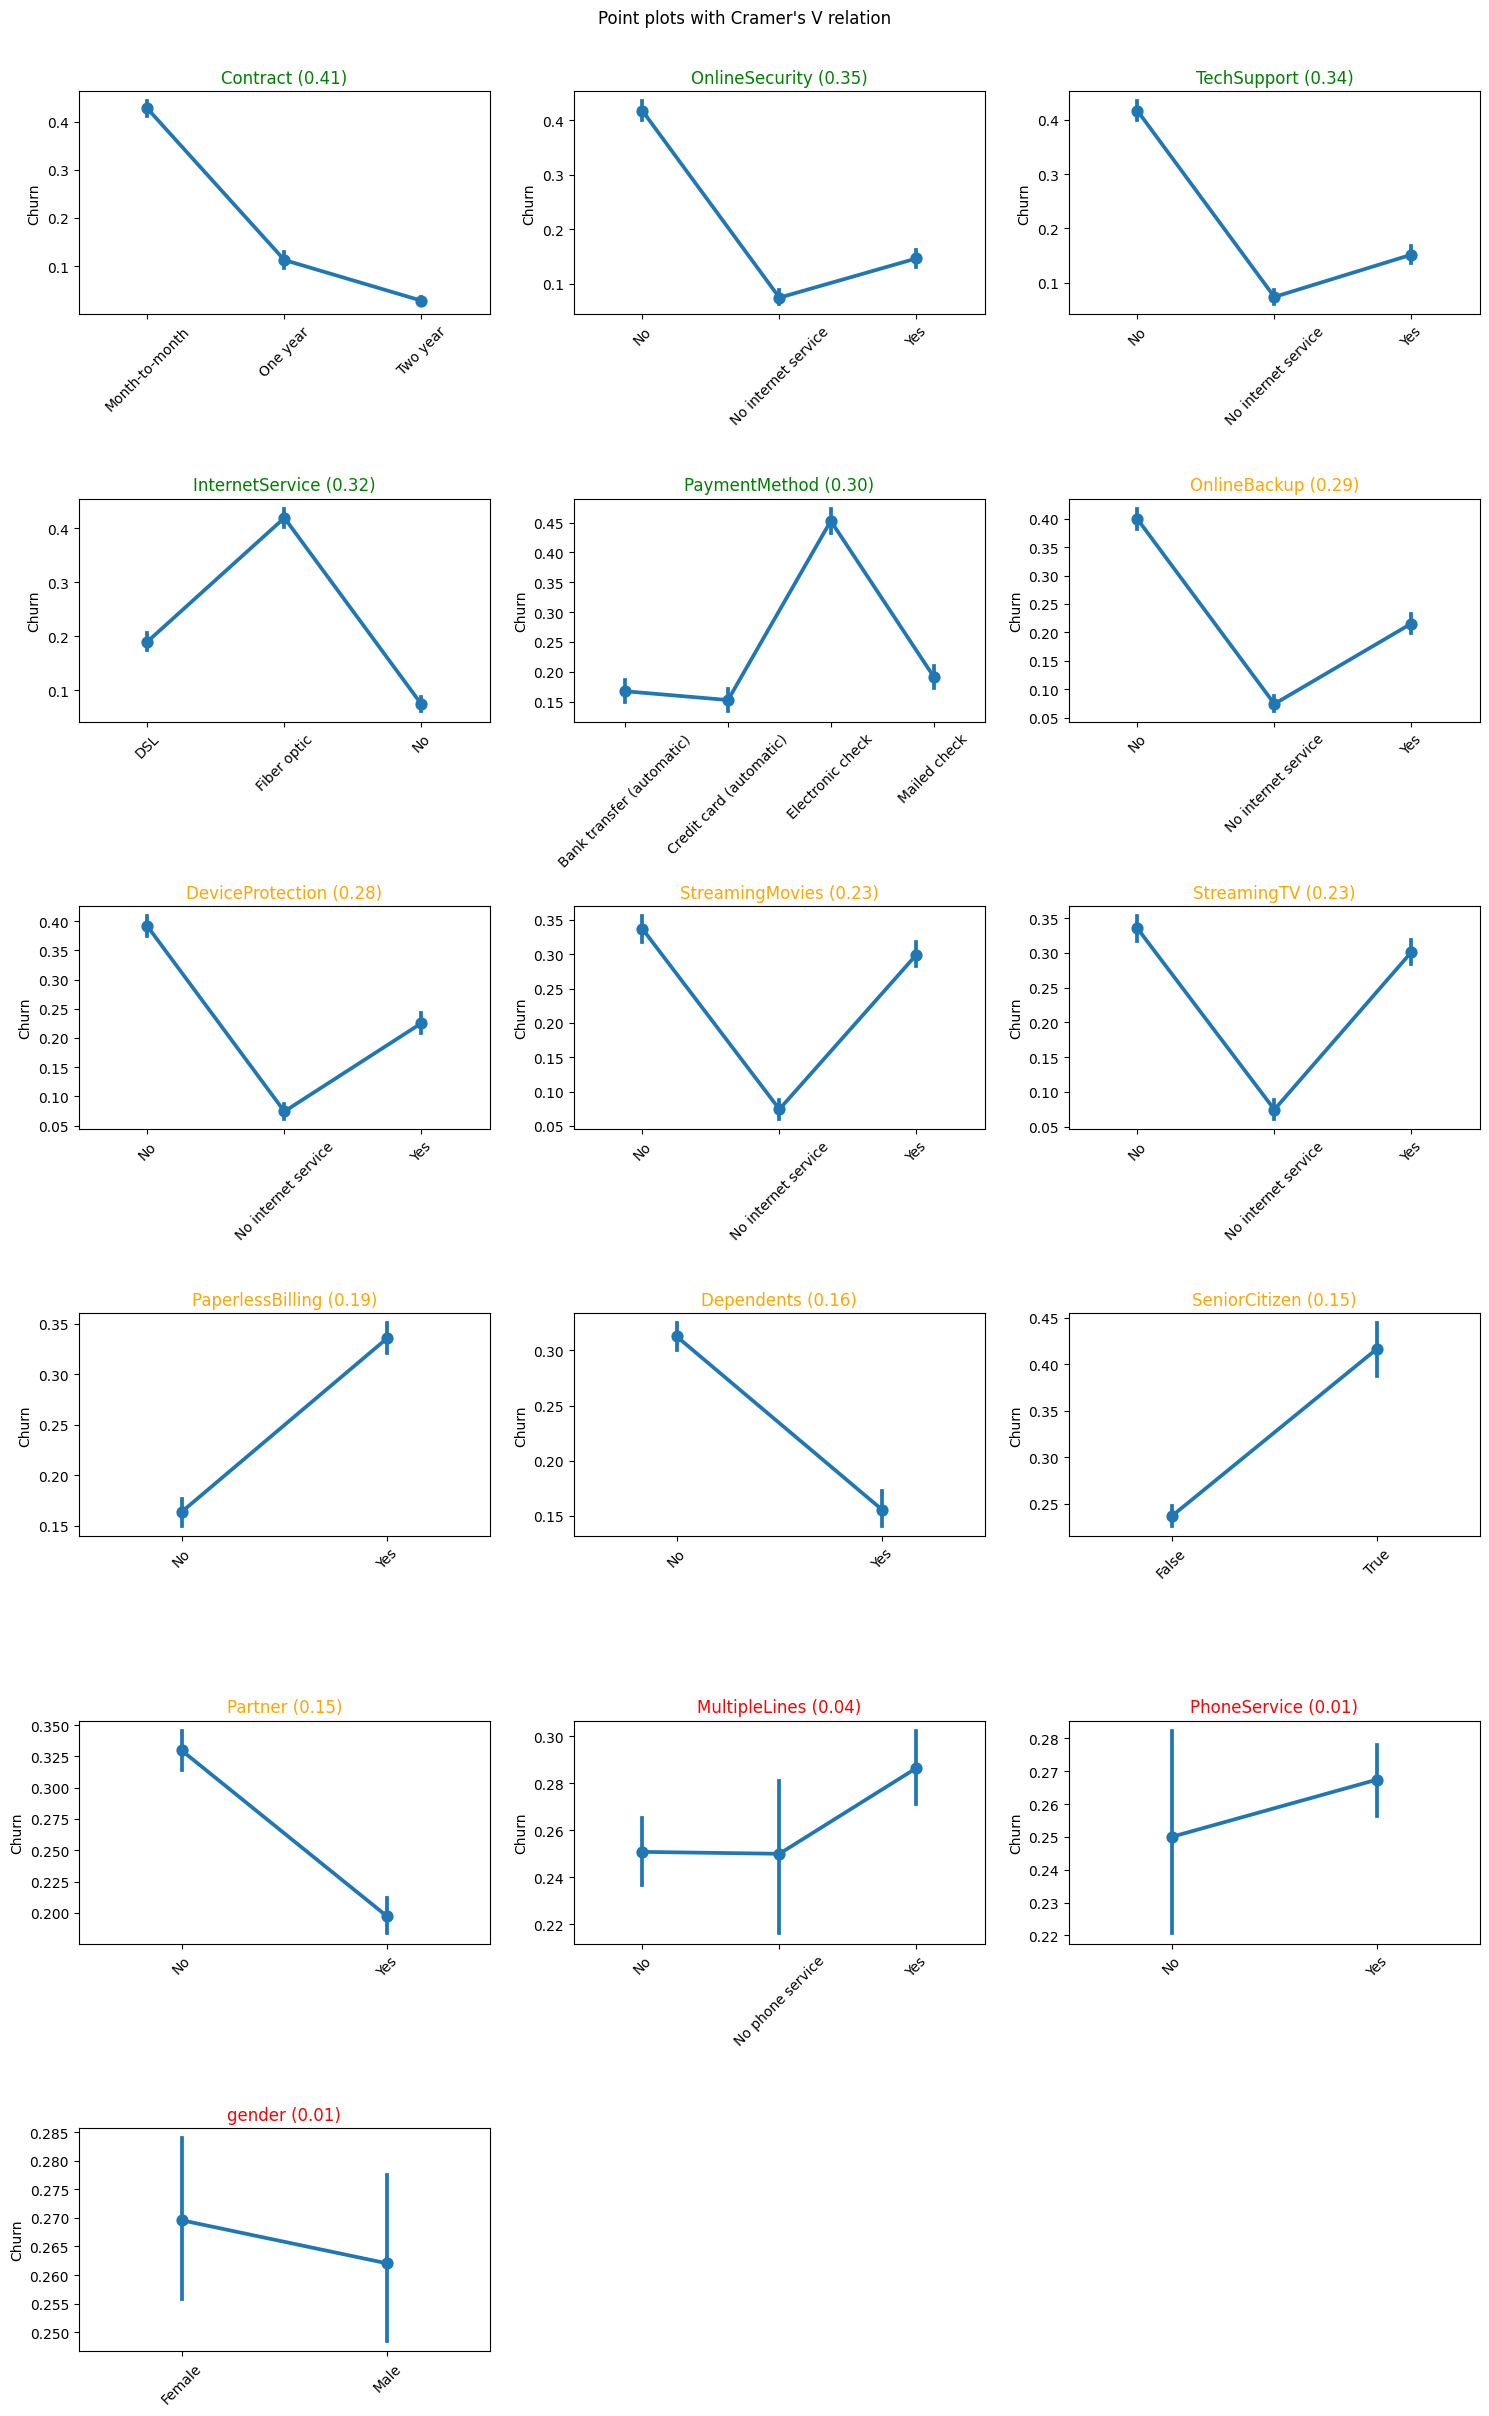

In [21]:
from typing import Literal

def define_relation_color_level(c_relation) ->Literal["green","orange","red"]:
    if c_relation<=0.1:
        return "red"
    if c_relation <= 0.3:
        return "orange"
    else:
        return "green"

def plotPointPlot(df, c_name: str, ax,c_relation: np.float64):
    sns.pointplot(df, x = c_name, y = "Churn", estimator = "mean", ax=ax)
    ax.tick_params(axis='x', labelrotation=45)
    c_rel_level = define_relation_color_level(c_relation)
    ax.set_xlabel("") # Xlabel is excessive for plot 
    ax.set_title(f"{c_name} ({c_relation:.2f})", color=c_rel_level)
    return ax

def plotPointPlots(df, plots_with_cramer:tuple[str, np.float64]):
    nrows, ncolumns = count_plot_sizes(len(plots_with_cramer))
    fig, axs = plt.subplots(nrows, ncolumns, figsize=(5 * ncolumns, 4 * nrows))
    
    for i, (c_name, c_relation) in enumerate(plots_with_cramer):
        ax = axs.flat[i] # type: ignore
        plotPointPlot(df, c_name,ax,c_relation)
    
    total_cells = nrows * ncolumns
    if total_cells > len(plots_with_cramer):
        for j in range(len(plots_with_cramer), total_cells):
            axs.flat[j].set_visible(False) # type: ignore
    
    print("Processed", len(plots_with_cramer)," plots")
    fig.suptitle("Point plots with Cramer's V relation", y = 1.005)
    plt.tight_layout()
    plt.show()

print("Interpretation: 0.00-0.10 negligible, 0.10-0.30 small, 0.30-0.50 medium, 0.50+ large")
df_encoded_churn = df.copy()
df_encoded_churn["Churn"] = LabelEncoder().fit_transform(df["Churn"])

sorted_data = calculate_cramers_on_data(df, columns_to_plot)
plotPointPlots(df_encoded_churn, sorted_data)


Analyzing the plot we can gather that features from green and yellow groups have good dividing capability. And red ones are not. Most of the features actually informative and can be used for analysis

We see that some features (like electronic check, fiber optic and No internet / phone service) give big impact on class dividing. That can lead to less reliable model on low informative features (i.e. model will perform worse with credit card rather than with electronic check)

Gender does not impact churn at all (sounds logical). But Partner, senior and dependents are.

Actually I think we need an additional analysis on customers *with* additional services (current plot gives high weight to people that do not use internet at all). The same for multiple Lines. Check below

Interpretation: 0.00-0.10 negligible, 0.10-0.30 small, 0.30-0.50 medium, 0.50+ large
Processed 8  plots


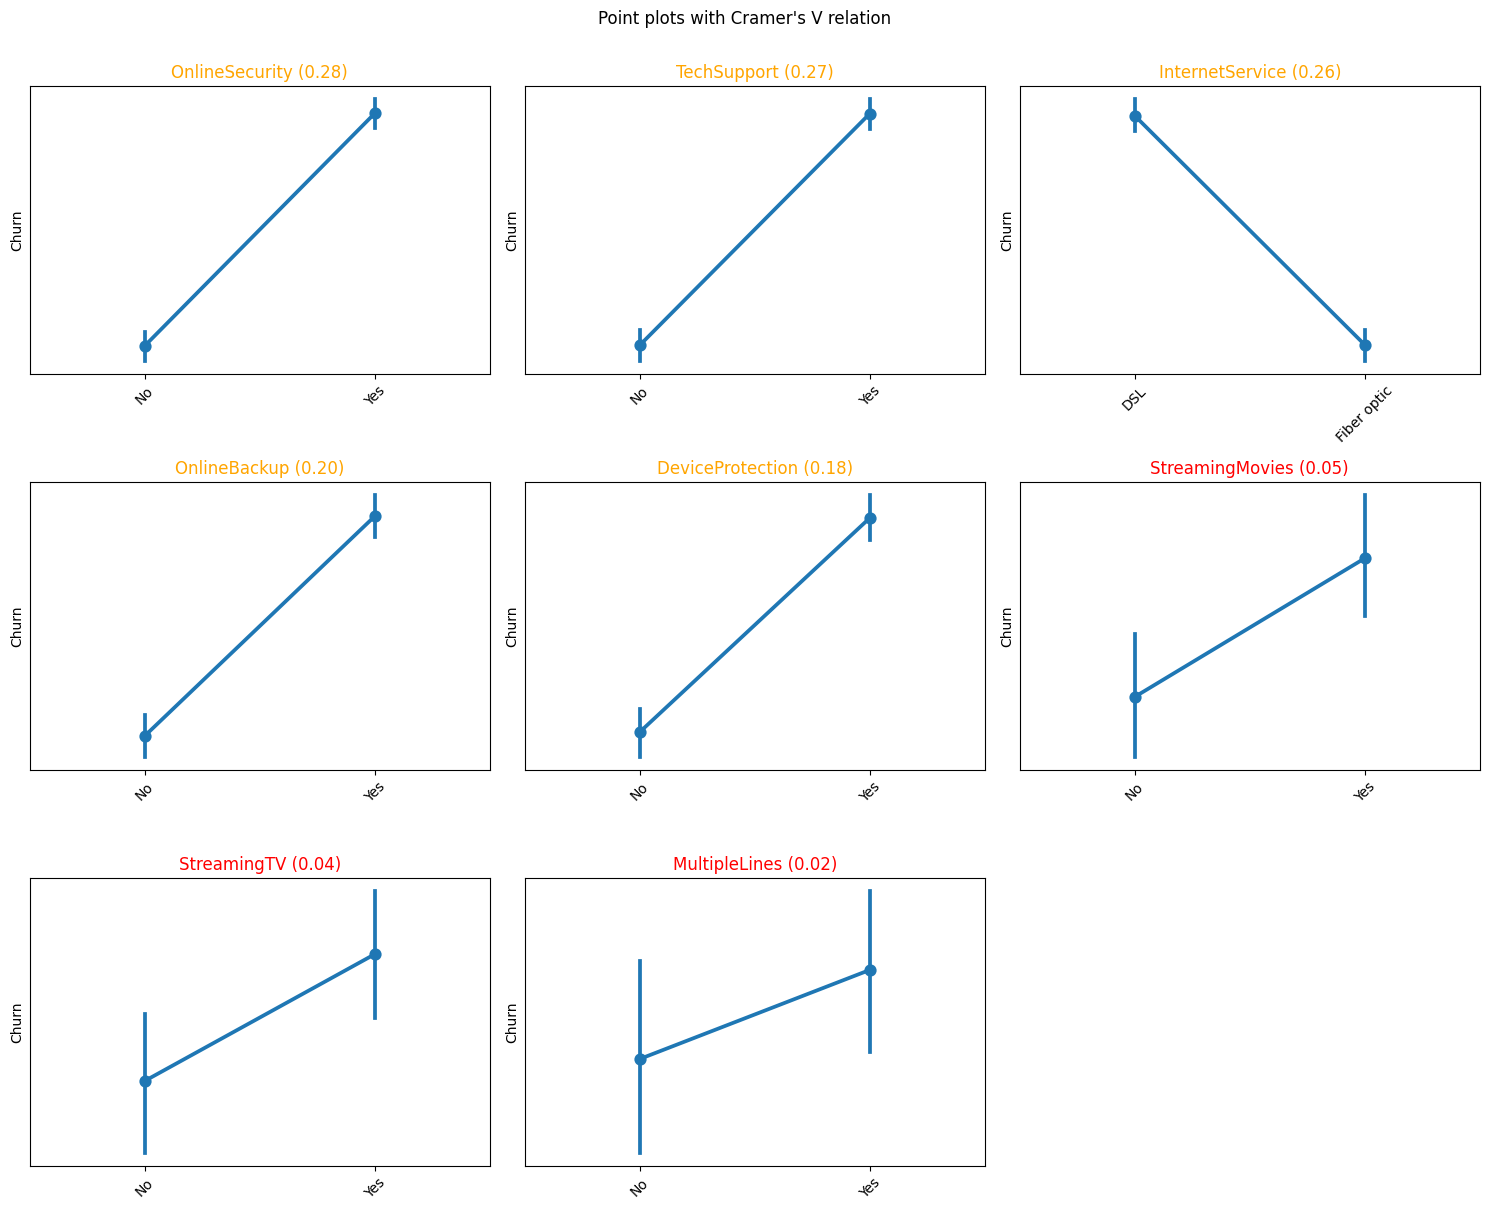

In [22]:
df_cramer_add = df[(df["InternetService"] != "No") & (df["PhoneService"] != "No")].copy()
for col in df_cramer_add.select_dtypes('category').columns:
    df_cramer_add[col] = df_cramer_add[col].cat.remove_unused_categories()

columns_to_plot = columns_to_plot - set(['gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'Contract', 'PaperlessBilling',
    'PaymentMethod'])

sorted_data = calculate_cramers_on_data(df_cramer_add, columns_to_plot)
print("Interpretation: 0.00-0.10 negligible, 0.10-0.30 small, 0.30-0.50 medium, 0.50+ large")
plotPointPlots(df_cramer_add, sorted_data)


We recalculate Cramer's V score for customers that actually use these services. We check is there really matter of using additional services fro churning. See that `Streaming movies` and `StreamingTV` score drops to negligible. That means streaming was not significant (For the customer actually matter do them have internet - that why previous score was high)

`Multiple lines` score does not significantly change. This proof that in our case multiple line feature does not affect churn

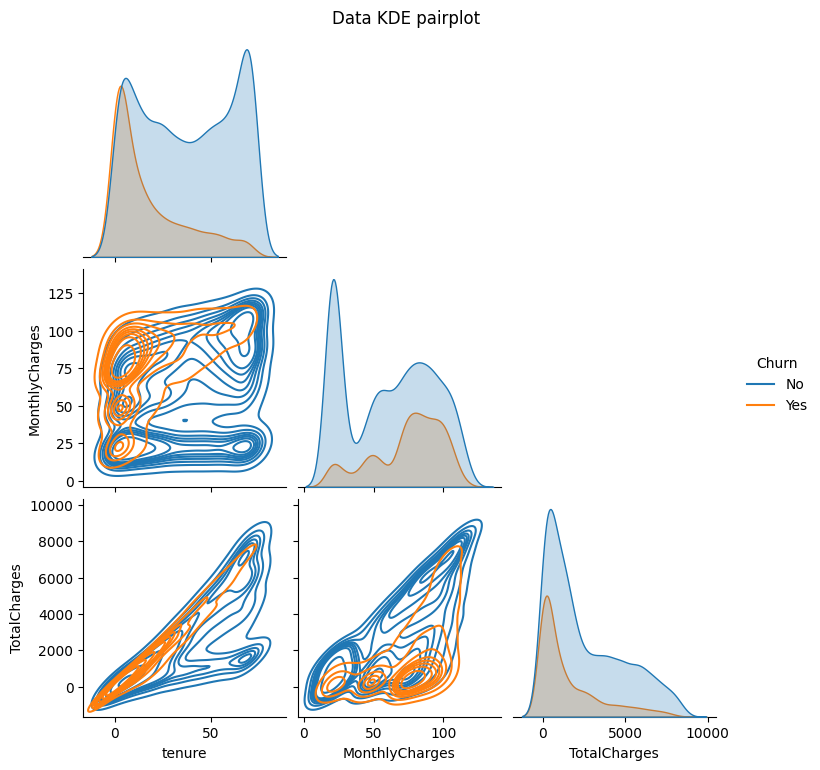

In [23]:
pairplot_fig = sns.pairplot(df.drop("SeniorCitizen", axis=1), kind="kde",hue="Churn", corner=True)
pairplot_fig.fig.suptitle("Data KDE pairplot", y = 1.02)
plt.show()

Densities

Looking at `tenure` density we can see a peak of churning. This peak is formed by people that are clients less than $\approx10$ months. That means the new customers are in red zone of churning. Otherwise loyal customers (50+ months with business) tend to continue using service

Looking at `monthlyCharges` density we see correlation: at big monthly charges there some local peaks of churned people

Looking at `totalCharges` we see combination of both features (As more `tenure` and `monthlyCharges` as more `totalCharges`). There is a peak of churn rate in 0-1300$ spend in a sum

---

MonthlyCharges vs Tenure (EDA)

This part of plot shows us that customers with high monthly charges and low tenure are frequently churning (look at weights in the left up zone). Monthly charges are ranging at low tenure zone and covering the most part of churned customers. That is insightful.

Also we see that even loyal customers with big charges have been churned (we see some points in the right up corner). 

Interesting that there are almost no one churned in the zone 20+ month and month charges up to 75

Underlining this part. We see that new customer + high charges is a danger zone for churning

---

Tenure vs TotalCharges (EDA)

As $TotalCharges = tenure * monthlyCharges$ (multicollinearity) we see almost linear combination with big weight of customers at zero tenure and zero total charges. That is proving described pattern of "new customer". Also we should notice that churned customers spread across high total charges zone  (refers to big monthly charges insight).

---

MonthlyCharges vs TotalCharges (EDA)

We see the correlation from different side (from monthly charges actually). Biggest weight has the zone with high monthly charges and low total charges (i.e. tenure). Also proving the point of "new customer and high bill" theory

In [24]:
%pip install altair prince vegafusion vl-convert-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 80.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 19.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.3 MB/s eta 0:00:00


In [25]:
import altair as alt
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [26]:
import prince

famd = prince.FAMD(
    n_components=2,
    n_iter=3,
    rescale_with_mean=True,
    rescale_with_std=True,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn", 
    handle_unknown="error",  # same parameter as sklearn.preprocessing.OneHotEncoder
)

X_features = df.drop(columns=['Churn', 'customerID'])

famd = famd.fit(X_features)

df_for_plot = df.set_index('Churn')
famd.plot(df_for_plot, x_component=0, y_component=1, color_rows_by='Churn')

alt.LayerChart(...)

In [27]:
# Top variables contributing to each component
for i in range(2):
    print(f"Top 5 contributors in component {i} ({famd.percentage_of_variance_[i]:.2f}% of variance)")
    top = famd.column_contributions_.sort_values(i, ascending=False)[i][:5]
    print(top.to_string())
    print()

Top 5 contributors in component 0 (9.76% of variance)
variable
InternetService    0.085456
StreamingMovies    0.084647
StreamingTV        0.084645
OnlineSecurity     0.084474
TechSupport        0.084415

Top 5 contributors in component 1 (5.24% of variance)
variable
tenure              0.112745
TotalCharges        0.101573
Contract            0.088668
DeviceProtection    0.050312
Partner             0.046053



From the FAMD (Factor analysis of mixed data) we see that dimensional reduction does not accomplish classifying task properly (clusters are mixed up). Component 0 + component 1 give $\approx15$% of churn variance that is not enough to explain target variable well

FAMD analysis tells us that such columns as `MonthlyCharges`, `DeviceProtection`, `TechSupport`, `StreamingMovies`, `StreamingTV`, `OnlineBackup` and `OnlineSecurity`, `InternetService` form a cloud that contains mostly not churned clients. Must note that most of them are the *optional service* offers and are highly correlated with each other (Without connected internet there wont be any other services). FAMD simply split clients that do not include additional services (and having low monthly charge obviously). That is why we need to be careful with that FAMD analysis.

# Cost-sensitive framing

Let's calculate losses for business side

Analyze how false positive and false negative affect the losses

In [28]:
avg_mnth_charge = df["MonthlyCharges"].mean()
print(f"Average monthly charge per client {avg_mnth_charge:.2f}$")
print()

Average monthly charge per client 64.80$



My idea is to use Restricted Mean Survival Time (RMST). This method will calculate "remaining time" based on customer current tenure

I will calculate the survival time by this formula:

$$
\text{E}\big[\text{remaining lifetime} \mid \text{survived to } T\big] \;=\; \frac{\displaystyle \int_{T}^{\tau} S(t)\,dt}{S(T)}
$$

Explanations:

- $S(t)$ – Surviving function (KaplanMeier)
- $T$ - current customer tenure
- $\tau$ – Our horizon for calculations (retention window)
- $\int_{T}^{\tau} S(t)\,dt$ – Area under surviving curve from $T$ to $\tau$. Will give us *non normalized* probability for survival time (As we calculate cut area from T to $\tau$)
 
- $S(T)$ – Probability of customer to survive to his current tenure. Used as normalization component (Normalize the cut area from T to $\tau$ as the customer actually survived)

In [29]:
%pip install -q lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.4 MB/s eta 0:00:00


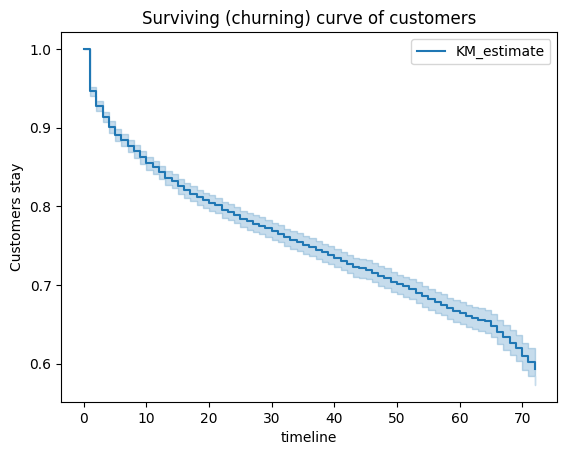

In [30]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(durations=df["tenure"], event_observed=df["Churn"] == "Yes")
kmf.plot_survival_function()
plt.title("Surviving (churning) curve of customers")
plt.ylabel("Customers stay")
plt.show()

In [31]:
survival_df = kmf.survival_function_

def expected_remaining_tenure(T, tau):
    surv = survival_df["KM_estimate"]
    times = survival_df.index.values

    # Filter times between T and tau
    mask = (times >= T) & (times <= tau)
    t = times[mask]
    s = surv[mask]

    # Numerical integration (trapezoidal rule)
    area = np.trapezoid(s, t) if len(t) > 1 else 0.0
    # S(T) — survival probability at current tenure
    s_T = surv[times == T] if T in times else surv[times <= T][-1]

    return area / s_T

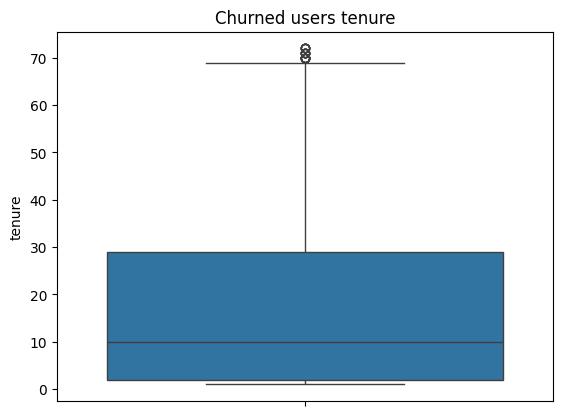

In [32]:
sns.boxplot(df[df["Churn"] == "Yes"]["tenure"])
plt.title("Churned users tenure")
plt.show()

If you recall the data (there were clusters of churned users with the high tenure) we should use median instead of mean (as most part of churned users were used service for 0-30 years and others are mostly data outliers)

Also let define the retention window as 24 month (we will check client's revenue for up to 2 years since the customer emerged)


In [33]:
churned_tenure_median = df[df["Churn"] == "Yes"]["tenure"].median()
print(f"Median tenure for churned customers: {churned_tenure_median}")

expected_churn_remaining = expected_remaining_tenure(churned_tenure_median, 24)
print(f"If we will lose an (average churning) customer right now. How long could he stay with us?")
print(f"Historically the customer would stay until {churned_tenure_median+ expected_churn_remaining.iloc[0]:.0f} month of a 2 year quarter")

Median tenure for churned customers: 10.0
If we will lose an (average churning) customer right now. How long could he stay with us?
Historically the customer would stay until 23 month of a 2 year quarter


In [34]:
avg_month_charges = df[df["Churn"] == "Yes"]["MonthlyCharges"].mean()
print(f"Average month charges in churned customers: {avg_month_charges:.2f}$")
print(f"The FN error will cost for us (based on averaged customer): {avg_month_charges * expected_churn_remaining.iloc[0]:.2f}$")

Average month charges in churned customers: 74.44$
The FN error will cost for us (based on averaged customer): 997.94$


Important note. I am describing best case in which customer will stay after our special offer. Should use A/B tests for final numbers

In next notebooks I will lean on [Harvard Business Review](https://static.fecredit.com.vn/Document/Th%C6%B0%20Vi%E1%BB%87n%20S%C3%A1ch/Merged/Mar%2016/Part%201.pdf) (22 page, "Marketing winning back lost customers")
and [Using Personalized, Targeted Discounts to Extend Customer LTV and Increase Loyalty](https://churnkey.co/blog/personalized-targeted-discounts-extend-customer-ltv-and-increase-loyalty/)


Define next strategy: we would propose a customer 20% discount for a 6 month period

In [35]:
discount = 0.2
months = 6
print(f"Strategy costs: {avg_month_charges*discount*months:.2f}$")

Strategy costs: 89.33$


As FP equals strategy implementation for non churning customers, the FP loses will be $89.33$ $

# Conclusion

## About preliminary analysis

NAs were deleted (only 11 na values in total charges)

no duplicates, no misleading data - data pipeline is ok

## Churning factors

- Tenure. New customers tend to suspend work with a business
- MonthlyCharges. Seeing a tendency in churning customers with high monthly charges
- Internet factor. Connected internet service brings changes in customer churn behavior

### Not significant factors

- Gender. Has small effect on splitting (Cramer's score) and can't be statistically proved (covers zero by 95% interval)
- StreamingTV / StreamingMovies / MultipleLines. Do not impact on customer churn. But the internet connection itself is a great factor (that why this StreamingX factor was calculated as significant firstly)

## Multicollinearity

Data have extreme amount of multicollinearity (see heatmap and pairplot). Should keep notion while model will be developing

## FAMD

- Dimension reduction explain only 15% of variance (do not split classes properly)
- Additional services form a cluster mostly not churned clients

## Cost sensitive analysis

- Losses with FN error: $997.94$ $
- Losses with FP error: $89.33$ $

Calculated based on 24 month retention window and 20% discount for 3 month strategy. Theoretical results, without A/B testing

## Recommendations

- Multicollinearity stable models (trees, ensembles) are preferred
- Gender, PhoneService and MultipleLines can be excluded at all
- Total charge is excessive due to linear interpretation of monthly charge and tenure
- The threshold should minimize FN error as the most expensive one